
--- MENU XỬ LÝ ẢNH ---
F: Biến đổi Fourier và hiển thị phổ tần số
L: Áp dụng Bộ lọc thông thấp Butterworth (BLPF)
H: Áp dụng Bộ lọc thông cao Butterworth (BHPE)
Q: Thoát chương trình


Đang áp dụng Bộ lọc thông cao Butterworth...


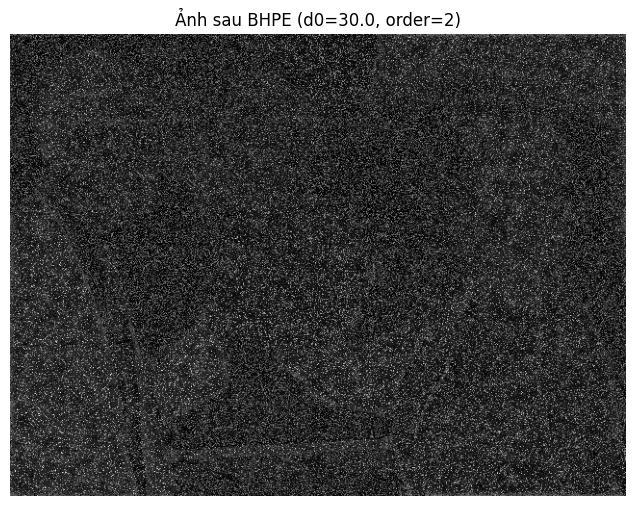

Đã hiển thị ảnh sau BHPE.

--- MENU XỬ LÝ ẢNH ---
F: Biến đổi Fourier và hiển thị phổ tần số
L: Áp dụng Bộ lọc thông thấp Butterworth (BLPF)
H: Áp dụng Bộ lọc thông cao Butterworth (BHPE)
Q: Thoát chương trình
Đang thoát chương trình. Tạm biệt!


In [5]:
from PIL import Image
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft2, ifft2, fftshift

# Đường dẫn đến ảnh của bạn
# Đảm bảo ảnh 'world_cup.jpg' nằm cùng thư mục với script này
image_path = 'balloons_noisy.png'

def perform_fft_and_shift(img_array):
    """Thực hiện FFT và dịch chuyển tần số."""
    # Thực hiện FFT
    f_transform = fft2(img_array)
    # Dịch chuyển tần số thấp về trung tâm
    f_shifted = fftshift(f_transform)
    # Lấy biên độ của phổ tần số
    magnitude_spectrum = np.abs(f_shifted)
    return magnitude_spectrum

def apply_butterworth_lowpass_filter(img_array, d0, order):
    """Áp dụng bộ lọc thông thấp Butterworth (BLPF)."""
    M, N = img_array.shape
    H = np.ones((M, N), dtype=float)
    center1 = M / 2
    center2 = N / 2
    
    for i in range(M):
        for j in range(N):
            # Tính khoảng cách Euclidean từ tâm
            r = math.sqrt((i - center1)**2 + (j - center2)**2)
            # Áp dụng công thức BLPF
            H[i, j] = 1 / (1 + (r / d0)**(2 * order))
            
    # Áp dụng bộ lọc trong miền tần số
    f_transform = fft2(img_array)
    f_shifted = fftshift(f_transform)
    
    filtered_spectrum = f_shifted * H
    
    # Dịch chuyển ngược lại và thực hiện IFFT
    f_ishifted = fftshift(filtered_spectrum)
    img_filtered = np.abs(ifft2(f_ishifted))
    
    return img_filtered

def apply_butterworth_highpass_filter(img_array, d0, order):
    """Áp dụng bộ lọc thông cao Butterworth (BHPE)."""
    M, N = img_array.shape
    H = np.ones((M, N), dtype=float)
    center1 = M / 2
    center2 = N / 2
    
    for i in range(M):
        for j in range(N):
            # Tính khoảng cách Euclidean từ tâm
            r = math.sqrt((i - center1)**2 + (j - center2)**2)
            # Áp dụng công thức BHPE (1 - BLPF)
            H[i, j] = 1 - (1 / (1 + (r / d0)**(2 * order)))
            
    # Áp dụng bộ lọc trong miền tần số
    f_transform = fft2(img_array)
    f_shifted = fftshift(f_transform)
    
    filtered_spectrum = f_shifted * H
    
    # Dịch chuyển ngược lại và thực hiện IFFT
    f_ishifted = fftshift(filtered_spectrum)
    img_filtered = np.abs(ifft2(f_ishifted))
    
    return img_filtered

def show_image(image_data, title):
    """Hàm để hiển thị ảnh bằng matplotlib."""
    plt.figure(figsize=(8, 6))
    plt.imshow(image_data, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- Chương trình chính ---
if __name__ == "__main__":
    # Mở ảnh gốc và chuyển đổi sang ảnh xám
    try:
        img_original = Image.open(image_path).convert('L')
        im_array_original = np.asarray(img_original)
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy ảnh '{image_path}'. Vui lòng đảm bảo ảnh nằm trong cùng thư mục.")
        exit()

    while True:
        print("\n--- MENU XỬ LÝ ẢNH ---")
        print("F: Biến đổi Fourier và hiển thị phổ tần số")
        print("L: Áp dụng Bộ lọc thông thấp Butterworth (BLPF)")
        print("H: Áp dụng Bộ lọc thông cao Butterworth (BHPE)")
        print("Q: Thoát chương trình")
        
        choice = input("Vui lòng chọn (F/L/H/Q): ").upper()

        if choice == 'F':
            print("Đang thực hiện Biến đổi Fourier (FFT)...")
            magnitude_spectrum = perform_fft_and_shift(im_array_original)
            # Log scale để dễ nhìn hơn phổ tần số
            show_image(np.log(1 + magnitude_spectrum), "Biên độ phổ Fourier (Log scale)")
            print("Đã hiển thị phổ Fourier.")
        elif choice == 'L':
            print("Đang áp dụng Bộ lọc thông thấp Butterworth...")
            # Các tham số cho BLPF
            d0_lowpass = 30.0  # Bán kính cắt tần số
            order_lowpass = 2  # Bậc của bộ lọc
            img_lowpassed = apply_butterworth_lowpass_filter(im_array_original, d0_lowpass, order_lowpass)
            show_image(img_lowpassed, f"Ảnh sau BLPF (d0={d0_lowpass}, order={order_lowpass})")
            print("Đã hiển thị ảnh sau BLPF.")
        elif choice == 'H':
            print("Đang áp dụng Bộ lọc thông cao Butterworth...")
            # Các tham số cho BHPE
            d0_highpass = 30.0 # Bán kính cắt tần số
            order_highpass = 2 # Bậc của bộ lọc
            img_highpassed = apply_butterworth_highpass_filter(im_array_original, d0_highpass, order_highpass)
            show_image(img_highpassed, f"Ảnh sau BHPE (d0={d0_highpass}, order={order_highpass})")
            print("Đã hiển thị ảnh sau BHPE.")
        elif choice == 'Q':
            print("Đang thoát chương trình. Tạm biệt!")
            break
        else:
            print("Lựa chọn không hợp lệ. Vui lòng thử lại.")